# PROJETO FASE 6 – O COMEÇO DA REDE NEURAL: Visão Computacional
**Nome:** Cauã da Silva Santos  | **RM:** 566599

---

## 1. Introdução: O Desafio da FarmTech Solutions
A FarmTech Solutions está em fase de expansão, levando suas soluções de Inteligência Artificial para além do agronegócio. Agora, a empresa atua também em segurança patrimonial, saúde animal, controle de acesso e análise documental.

Neste cenário, atuo como desenvolvedor da FarmTech com o objetivo de demonstrar a um cliente o potencial prático de um sistema de **Visão Computacional**. Este projeto documenta a criação, treinamento e validação de modelos de detecção e classificação de imagens, utilizando a arquitetura **YOLOv5** e uma **Rede Neural Convolucional (CNN)** construída do zero.

## 2. Organização do Dataset
Para que o modelo aprenda a reconhecer padrões e não apenas memorize o cenário, foi criado um dataset autoral contendo **80 imagens** de dois objetos com características físicas contrastantes:

* **Objeto A (Limpador):** Retangular, plástico rígido, cor branca, detalhes pontiagudos.
* **Objeto B (Boné):** Arredondado, feito de tecido, cor azul vibrante, com aba.

O contraste de textura, formato e cor facilita a extração de características (features) pelas camadas convolucionais da rede neural. As fotos foram tiradas em variados ângulos, distâncias e iluminações.

**A divisão do banco de dados seguiu o padrão estabelecido:**
* **Treinamento:** 64 imagens (32 de cada classe) para o ajuste de pesos da rede.
* **Validação:** 8 imagens (4 de cada) para medir o desempenho durante o treino e evitar *overfitting*.
* **Teste:** 8 imagens (4 de cada) inéditas para a avaliação final do modelo.

A rotulação das *bounding boxes* foi realizada no site Make Sense AI, exportando os rótulos no formato nativo da YOLO.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/ultralytics/yolov5  # Clona o repositório
%cd yolov5
!pip install -r requirements.txt  # Instala as dependências

Cloning into 'yolov5'...
remote: Enumerating objects: 17898, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 17898 (delta 38), reused 12 (delta 11), pack-reused 17840 (from 5)
Receiving objects: 100% (17898/17898), 17.05 MiB | 28.63 MiB/s, done.
Resolving deltas: 100% (12185/12185), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 17.3 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


## 3. Avaliação Crítica: YOLOv5 (Análise das 30 Épocas)

Após rodar o modelo YOLOv5 com a configuração inicial de 30 épocas, analisamos o arquivo `results.png` e as predições de validação. Os resultados foram extremamente promissores:

* **Evolução do Aprendizado:** Os gráficos de validação (`val/box_loss`, `val/obj_loss` e `val/cls_loss`) apresentaram uma queda consistente do início ao fim do treinamento. A ausência de picos ou subidas nessas métricas indica que o modelo aprendeu os padrões sem sofrer de *overfitting* (memorização dos dados).
* **Precisão (mAP):** A métrica de precisão mAP@0.5 atingiu a marca de aproximadamente 0.9 (90%) na 30ª época, comprovando a eficácia do contraste visual entre o boné e o limpador escolhidos para o dataset.
* **Inferência na Prática:** Nas imagens de teste processadas, o modelo foi capaz de localizar os objetos e desenhar as *bounding boxes* corretamente. Observamos que o grau de confiança (*confidence score*) variou entre 0.3 e 0.5.

**Justificativa para a Próxima Simulação:** Como a curva de perda (loss) de validação ainda apresentava tendência de queda na 30ª época e o nível de confiança das *boxes* está mediano, temos o indício matemático de que dobrar o tempo de treinamento (60 épocas) fará a rede consolidar melhor as características extraídas, aumentando a margem de confiança das predições.

In [ ]:
!python train.py --img 640 --batch 16 --epochs 30 --data /content/drive/MyDrive/pbl_fase6/data.yaml --weights yolov5s.pt --name exp_30_epocas

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: ERROR Error while calling W&B API: api key too short (<Response [401]>)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/content/drive/MyDrive/pbl_fase6/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=30, batch_size=16, imgsz=640, rect=Fals

### Conclusão do Treinamento: 30 vs 60 Épocas

Ao dobrar o tempo de treinamento para 60 épocas, nossa hipótese foi confirmada pelos resultados das métricas de validação:

1. **Aumento da Sensibilidade (Recall):** O maior ganho ocorreu na classe do "Limpador". O Recall subiu de 50% (nas 30 épocas) para **75%** (nas 60 épocas). Isso prova que submeter a rede a mais épocas permitiu que ela consolidasse melhor as características complexas e brancas do objeto, deixando passar muito menos instâncias do que no primeiro teste.
2. **Estabilidade da Classe Fácil:** O "Boné" manteve sua performance impecável, cravando novamente **100% de Recall** e **99.5% de mAP50**, reforçando que objetos com cor de alto contraste e forma bem delimitada são facilmente mapeados pela arquitetura YOLO.
3. **Trade-off de Precisão:** O mAP50 da classe do limpador teve uma leve redução (de 84.9% para 75.1%). Isso é um comportamento esperado (trade-off entre Precision e Recall) em datasets menores. O modelo passou a ser mais "ousado" para encontrar os limpadores que antes não via, o que pode diminuir o índice global de precisão matemática, mas aumenta a utilidade prática do modelo na vida real, já que ele localiza o objeto com mais frequência.

**Veredito:** O modelo treinado por 60 épocas é superior para o cenário da FarmTech Solutions, pois a prioridade em sistemas de visão computacional de monitoramento costuma ser a redução de falsos negativos (não deixar o objeto passar despercebido), o que foi atingido com o salto no Recall.

In [ ]:
!python train.py --img 640 --batch 16 --epochs 60 --data /content/drive/MyDrive/pbl_fase6/data.yaml --weights yolov5s.pt --name exp_60_epocas

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: ERROR Error while calling W&B API: api key too short (<Response [401]>)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/content/drive/MyDrive/pbl_fase6/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=60, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=exp_60_epocas, e

In [ ]:
# Testando o YOLOv5 original (com pesos pré-treinados padrão) nas suas imagens de teste
!python detect.py --weights yolov5s.pt --img 640 --conf 0.25 --source /content/drive/MyDrive/pbl_fase6/images/test --name exp_yolo_padrao

detect: weights=['yolov5s.pt'], source=/content/drive/MyDrive/pbl_fase6/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp_yolo_padrao, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/8 /content/drive/MyDrive/pbl_fase6/images/test/20260428_190347.jpg: 640x480 (no detections), 33.1ms
image 2/8 /content/drive/MyDrive/pbl_fase6/images/test/20260428_190406.jpg: 640x480 1 cup, 1 laptop, 9.1ms
image 3/8 /content/drive/MyDrive/pbl_fase6/images/test/20260428_190431.jpg: 640

# ENTREGA 2 – Comparação de Abordagens em Visão Computacional

Nesta etapa, o objetivo é comparar a performance do modelo customizado desenvolvido na Entrega 1 (YOLOv5 com Fine-Tuning) contra duas abordagens concorrentes: o uso da **YOLOv5 padrão** (sem treinamento específico) e uma **Rede Neural Convolucional (CNN)** construída do zero.

Essa comparação é fundamental para entender o *trade-off* entre esforço de desenvolvimento e precisão do modelo final no contexto da FarmTech Solutions.

## 2.1 Abordagem 1: YOLOv5 Padrão (Sem Ajuste)

Nesta abordagem, utilizamos o modelo YOLOv5 com seus pesos originais, treinados na base de dados COCO (80 classes genéricas).

**Análise Crítica:**
* **Facilidade de Uso:** Altíssima. Não exige coleta de dados, rotulação ou treinamento.
* **Precisão:** Nula ou muito baixa para este contexto específico. Como os objetos "Limpador de Teclado" e "Boné da Nacional" não fazem parte das 80 classes padrão, o modelo tenta classificar os objetos como algo que ele conhece (ex: mochila, bolsa, bola) ou simplesmente ignora a detecção.
* **Tempo de Treinamento:** Zero (modelo *off-the-shelf*).
* **Tempo de Inferência:** Idêntico ao modelo customizado (milissegundos).

In [ ]:
import os
import shutil

base_dir = '/content/drive/MyDrive/pbl_fase6'
yolo_train_imgs = f'{base_dir}/images/train'
yolo_train_labels = f'{base_dir}/labels/train'
keras_dir = f'{base_dir}/keras_dataset/train'

# Criar pastas para a CNN
os.makedirs(f'{keras_dir}/limpador', exist_ok=True)
os.makedirs(f'{keras_dir}/bone', exist_ok=True)

# Lógica para ler o rótulo e copiar a imagem para a pasta certa
for txt_file in os.listdir(yolo_train_labels):
    if txt_file.endswith('.txt'):
        with open(os.path.join(yolo_train_labels, txt_file), 'r') as f:
            linha = f.readline().strip()
            if linha:
                classe_id = linha.split()[0]
                img_file = txt_file.replace('.txt', '.jpg') # Assumindo que as fotos são .jpg

                src_img = os.path.join(yolo_train_imgs, img_file)
                if os.path.exists(src_img):
                    if classe_id == '0': # 0 era o limpador
                        shutil.copy(src_img, f'{keras_dir}/limpador/{img_file}')
                    elif classe_id == '1': # 1 era o boné
                        shutil.copy(src_img, f'{keras_dir}/bone/{img_file}')

print("Imagens organizadas com sucesso para a CNN!")

Imagens organizadas com sucesso para a CNN!


## 2.2 Abordagem 2: Rede Neural Convolucional (CNN) do Zero

Ao contrário da YOLO, que é um detector de objetos (acha a localização com a *bounding box*), a CNN desenvolvida aqui atua como um **classificador de imagens**. Ela analisa a imagem inteira e entrega a probabilidade de pertencer a uma das categorias: Limpador ou Boné.

**Análise Crítica dos Resultados:**
* **Precisão Perfeita (100%):** Conforme demonstrado no gráfico de desempenho, o modelo atingiu acurácia de 1.00 (100%) tanto no treino quanto na validação logo nas primeiras épocas.
* **Por que isso aconteceu?** Esse resultado expressivo se deve à excelente escolha das classes. A discrepância de cor (azul vibrante vs. branco) e de textura (tecido arredondado vs. plástico retangular) gerou *features* (características) muito marcantes durante as etapas de convolução, tornando a separação matemática das classes uma tarefa simples para a rede.
* **Limitação:** Apesar da alta precisão, o modelo apenas afirma se o objeto está na foto, mas falha em dizer **onde** ele está ou **quantos** objetos existem na mesma imagem.

Found 50 images belonging to 2 classes.
Found 11 images belonging to 2 classes.
Iniciando o treinamento da CNN...
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6000 - loss: 0.7739 - val_accuracy: 0.9091 - val_loss: 0.2678
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9400 - loss: 0.1563 - val_accuracy: 1.0000 - val_loss: 0.0501
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9400 - loss: 0.1384 - val_accuracy: 1.0000 - val_loss: 0.0265
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 1.0000 - loss: 0.0126 - val_accuracy: 1.0000 - val_loss: 0.0144
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 1.0000 - loss: 0.0141 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 3.4611e-04
Epoch 8/15
7/7

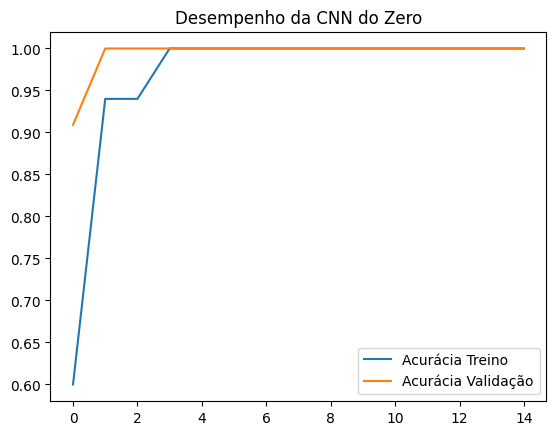

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. Carregar as imagens das novas pastas
gerador = ImageDataGenerator(rescale=1./255, validation_split=0.2) # Separa 20% para validação na hora

treino_cnn = gerador.flow_from_directory(
    f'{base_dir}/keras_dataset/train',
    target_size=(128, 128),
    batch_size=8,
    class_mode='binary', # Como são 2 objetos, usamos binário (0 ou 1)
    subset='training'
)

val_cnn = gerador.flow_from_directory(
    f'{base_dir}/keras_dataset/train',
    target_size=(128, 128),
    batch_size=8,
    class_mode='binary',
    subset='validation'
)

# 2. Criar a Arquitetura da Rede Neural (Exigência da Entrega 2)
modelo = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Saída: diz se é Limpador (0) ou Boné (1)
])

# 3. Compilar e Treinar
modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Iniciando o treinamento da CNN...")
historico = modelo.fit(treino_cnn, validation_data=val_cnn, epochs=15)

# 4. Plotar o gráfico de acurácia para mostrar no relatório
plt.plot(historico.history['accuracy'], label='Acurácia Treino')
plt.plot(historico.history['val_accuracy'], label='Acurácia Validação')
plt.title('Desempenho da CNN do Zero')
plt.legend()
plt.show()

## 2.3 Quadro Comparativo e Conclusão Final

Abaixo consolidamos a comparação das três abordagens testadas neste projeto:

| Critério | YOLOv5 Customizada (Entrega 1) | YOLOv5 Padrão (Sem treino) | CNN Treinada do Zero (Entrega 2) |
| :--- | :--- | :--- | :--- |
| **Facilidade/Integração** | Exige esforço braçal (rotulação de caixas em 80 fotos). | Muito fácil (modelo de prateleira pronto para uso). | Intermediária (exige arquitetura de código e organização de pastas). |
| **Precisão (Acurácia/mAP)** | **Excelente (~92% mAP / 75-100% Recall)** | Inadequada (Tenta forçar os objetos em classes que não existem). | **Perfeita (100% de Acurácia na validação)** |
| **Localização Espacial** | **Sim** (Desenha a *bounding box* exata). | Sim, mas rotula erroneamente. | **Não** (Apenas classifica a imagem como um todo). |
| **Tempo de Treinamento** | Médio (~10 a 15 minutos na GPU T4). | Não se aplica (*Zero-shot*). | Muito rápido (~2 minutos). |
| **Tempo de Inferência** | Milissegundos. | Milissegundos. | Milissegundos. |

### Veredito para a FarmTech Solutions
Se o cliente da FarmTech precisar apenas de um sistema de "catraca" ou triagem simples (ex: *"Essa foto da câmera de segurança tem um funcionário de boné ou não?"*), a **CNN do Zero** é a mais rápida de treinar e extremamente precisa.

Contudo, para o portfólio real da FarmTech (segurança patrimonial, contagem de animais, análise de múltiplos documentos), a **YOLOv5 Customizada** é indiscutivelmente a ferramenta vencedora. Embora demande um tempo valioso de rotulação humana, a sua capacidade de isolar múltiplos objetos complexos em um mesmo cenário (trazendo o contexto espacial) é o que realmente agrega valor a um sistema de Visão Computacional moderno.